# Week 4 – Graph Data Management and Social Network Analysis with Python and Gephi

**Course:** Data Management (hands-on)

## Learning objectives

- Understand how CSV edge-list data represents a graph
- Load and inspect a graph dataset
- Build an undirected graph using NetworkX
- Prepare graph files that can also be imported into Gephi
- Analyze degree, betweenness centrality, PageRank, and communities
- Highlight important nodes and explain their role in the network

## Required libraries

This notebook uses **pandas**, **networkx**, **matplotlib**, and **numpy**.

**Community detection:** if **python-louvain** is installed, we use Louvain modularity; otherwise NetworkX `greedy_modularity_communities`.

**Optional:** **pyvis** for interactive HTML visualizations (skipped automatically if not installed).


## 1. Introduction

This exercise uses a **sampled Amazon product co-purchasing network**:

- **Nodes** represent **products** (product identifiers).
- **Edges** connect products that were **frequently bought together** (co-purchasing).
- We treat the network as **undirected**: if A is bought with B, we do not distinguish direction; the relationship is symmetric for our analysis.

Graphs like this support questions such as which products sit at the “center” of demand, which ones **bridge** different product groups, and whether products form **communities** (clusters).

**Tools:** Python gives **reproducible** analysis and exports; **Gephi** is strong for **interactive** exploration and presentation-quality layouts.


In [1]:
# --- Imports and project paths (relative to repository root) ---
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx

warnings.filterwarnings("ignore", category=FutureWarning)


def find_project_root() -> Path:
    """Locate repo root by finding data/raw/amazon_sampled_graph.csv walking up from cwd."""
    here = Path.cwd().resolve()
    for d in [here, *here.parents]:
        marker = d / "data" / "raw" / "amazon_sampled_graph.csv"
        if marker.is_file():
            return d
    raise FileNotFoundError(
        "Could not find data/raw/amazon_sampled_graph.csv. "
        "Open Jupyter from the repository root or from notebooks/week4/."
    )


PROJECT_ROOT = find_project_root()
# Relative segments only (no absolute literals in paths)
DATA_PATH = PROJECT_ROOT / "data" / "raw" / "amazon_sampled_graph.csv"
OUT_DIR = PROJECT_ROOT / "outputs" / "week4"
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Paths below are relative to the detected project root (no absolute paths printed)
print("Data file:", "data/raw/amazon_sampled_graph.csv")
print("Output folder:", "outputs/week4/")


Data file: data/raw/amazon_sampled_graph.csv
Output folder: outputs/week4/


## 2. Load the Dataset

We load the edge list with **pandas**, validate **Source** and **Target**, check **missing** values and **duplicate** edges, and preview the structure.

**Edge list:** each row is one undirected co-purchase relationship (we will treat it as undirected when building the graph).


In [2]:
# --- Load CSV and normalize column names for Source / Target ---


def normalize_edge_columns(df: pd.DataFrame) -> pd.DataFrame:
    """Ensure columns are exactly 'Source' and 'Target' (case-insensitive match)."""
    lower = {c.lower(): c for c in df.columns}
    if "source" not in lower or "target" not in lower:
        raise ValueError(
            "Expected columns Source and Target (any casing). "
            f"Found: {list(df.columns)}"
        )
    return df.rename(
        columns={lower["source"]: "Source", lower["target"]: "Target"}
    )[["Source", "Target"]]


# Load edge list
edges_df = pd.read_csv(DATA_PATH)
edges_df = normalize_edge_columns(edges_df)

# Basic inspection
display(edges_df.head(10))
print("Shape (rows, columns):", edges_df.shape)
print("Missing values per column:\n", edges_df.isna().sum())

# Duplicated rows (identical Source, Target)
dup_mask = edges_df.duplicated()
print("Fully duplicate rows:", int(dup_mask.sum()))

# Undirected duplicate check: (a,b) vs (b,a) treated as same edge
pairs = edges_df.apply(
    lambda r: tuple(sorted([r["Source"], r["Target"]])), axis=1
)
print("Unique undirected edge pairs:", pairs.nunique())
print("Rows - unique undirected pairs:", int(edges_df.shape[0] - pairs.nunique()))


,Source,Target
0,161797,36000
1,161797,521221
2,272396,38365
3,272396,476945
4,272396,477105
5,272396,513227
6,215057,38365
7,366610,55488
8,366610,246481
9,366610,377917


Shape (rows, columns): (2178, 2)
Missing values per column:
 Source    0
Target    0
dtype: int64
Fully duplicate rows: 0
Unique undirected edge pairs: 2178
Rows - unique undirected pairs: 0


**Interpretation:** The file is a clean **edge list**. Missing values should be zero for a valid graph import. Duplicate rows (or reversed duplicates) inflate degree; for this teaching notebook we keep the loaded graph as-is unless you add a deduplication step in your own extension exercise.


## 3. Build an Undirected Graph

We use `networkx.from_pandas_edgelist` with `create_using=nx.Graph()` so edges are **undirected** and parallel edges collapse to a single edge in NetworkX.


In [3]:
# --- Build undirected graph from edge list ---
G = nx.from_pandas_edgelist(
    edges_df, source="Source", target="Target", create_using=nx.Graph()
)

n_nodes = G.number_of_nodes()
n_edges = G.number_of_edges()
density = nx.density(G)
components = list(nx.connected_components(G))
n_comp = nx.number_connected_components(G)
lcc = max(components, key=len)
lcc_n = len(lcc)

print("Number of nodes:", n_nodes)
print("Number of edges:", n_edges)
print("Graph density:", round(density, 6))
print("Number of connected components:", n_comp)
print("Size of largest connected component (nodes):", lcc_n)

# Keep largest connected component as main analysis graph when graph is disconnected or very large
G_lcc = G.subgraph(lcc).copy()


Number of nodes: 1000
Number of edges: 2178
Graph density: 0.00436
Number of connected components: 1
Size of largest connected component (nodes): 1000


**Interpretation:** **Density** is the fraction of possible edges that exist; sparse retail graphs are typical. Multiple **components** mean some products are only co-purchased within an isolated island; analysts often focus on the **largest connected component (LCC)** for path-based metrics.


## 4. Prepare Files for Gephi

We export:

- `outputs/week4/amazon_edges_for_gephi.csv` — edge list (**Source**, **Target**)
- `outputs/week4/amazon_nodes_for_gephi.csv` — node table (**Id**; optional **Label**)
- `outputs/week4/amazon_graph_for_gephi.gexf` — single-file graph (optional convenience)

Paths are created with `pathlib` under **`outputs/week4/`** (relative to the project root).


In [4]:
# --- Minimal Gephi exports (topology only) ---
nodes_basic = pd.DataFrame({"Id": list(G.nodes()), "Label": list(G.nodes())})
edges_export = edges_df.copy()

nodes_basic.to_csv(OUT_DIR / "amazon_nodes_for_gephi.csv", index=False)
edges_export.to_csv(OUT_DIR / "amazon_edges_for_gephi.csv", index=False)
nx.write_gexf(G, OUT_DIR / "amazon_graph_for_gephi.gexf")

print("Wrote:")
for name in [
    "amazon_nodes_for_gephi.csv",
    "amazon_edges_for_gephi.csv",
    "amazon_graph_for_gephi.gexf",
]:
    print(" ", (OUT_DIR / name).relative_to(PROJECT_ROOT))


Wrote:
  outputs/week4/amazon_nodes_for_gephi.csv
  outputs/week4/amazon_edges_for_gephi.csv
  outputs/week4/amazon_graph_for_gephi.gexf


### How to import into Gephi (student checklist)

1. **Open** Gephi → **New Project**.
2. **Import** `amazon_edges_for_gephi.csv` as an **edge table** (or import **Spreadsheet**); choose **Undirected** if asked.
3. Run a **layout**: **ForceAtlas2** for organic clusters; **Yifan Hu** can scale better on larger graphs.
4. **Appearance → Nodes → Size**: map **Degree** (after running **Average Degree** in Statistics, or use the enriched export in Section 11).
5. **Appearance → Nodes → Partition/Color**: use **modularity class** (run **Modularity** in Statistics) or the **Community** column from the enriched CSV in Section 11.
6. **Highlight** hubs and bridges using **Degree**, **Betweenness**, or the boolean flags in the enriched node table.

**Note:** Python gives reproducible numbers; Gephi is ideal for **interactive** layout and storytelling slides.


## 5. Graph Visualization in Python

We draw a **spring layout** (force-directed, Fruchterman–Reingold in NetworkX). If the graph is dense or large, we visualize the **LCC** or a **random subgraph** for readability.


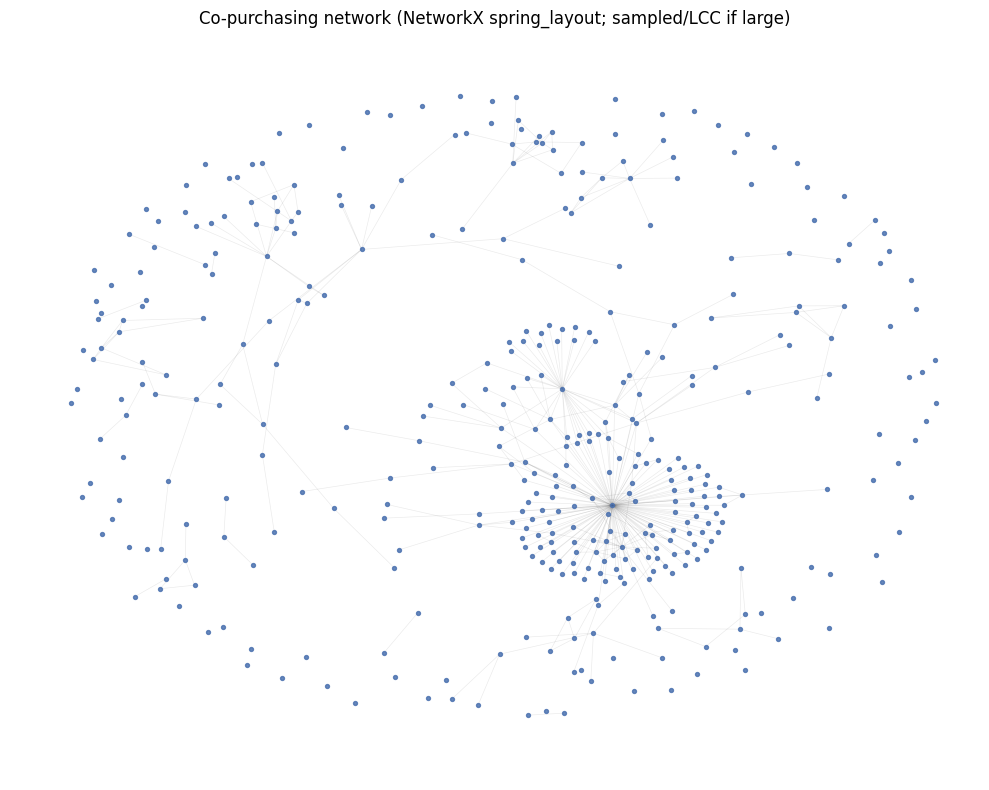

Nodes drawn: 400 Edges drawn: 393


In [5]:
# --- Matplotlib layout: prefer LCC; subsample if still heavy ---
rng = np.random.default_rng(42)
G_vis = G_lcc
if G_vis.number_of_nodes() > 400:
    sample_nodes = set(rng.choice(list(G_vis.nodes()), size=400, replace=False))
    G_vis = G_vis.subgraph(sample_nodes).copy()

pos = nx.spring_layout(G_vis, seed=42, k=0.15)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G_vis, pos, alpha=0.08, width=0.5)
nx.draw_networkx_nodes(G_vis, pos, node_size=8, node_color="#4C72B0", alpha=0.85)
plt.axis("off")
plt.title("Co-purchasing network (NetworkX spring_layout; sampled/LCC if large)")
plt.tight_layout()
plt.show()

print("Nodes drawn:", G_vis.number_of_nodes(), "Edges drawn:", G_vis.number_of_edges())


**Interpretation:** This view is useful for **quick sanity checks**. For publication or exploration, **Gephi** (or optional **pyvis**) typically produces clearer, interactive layouts at scale.


In [6]:
# --- Optional: pyvis interactive HTML (skipped if not installed / on error) ---
import numbers

try:
    from pyvis.network import Network

    def _pyvis_node_id(n):
        # pyvis only accepts built-in int or str (numpy.integer fails isinstance(..., int))
        if isinstance(n, bool):
            return str(n)
        if isinstance(n, numbers.Integral):
            return int(n)
        return str(n)

    net = Network(height="500px", width="100%", bgcolor="#ffffff", font_color="#333333")
    net.barnes_hut()
    sub_raw = list(G_vis.nodes())[:200]
    id_map = {n: _pyvis_node_id(n) for n in sub_raw}
    H = nx.Graph()
    H.add_nodes_from(id_map[n] for n in sub_raw)
    for u, v in G_vis.subgraph(sub_raw).edges():
        H.add_edge(id_map[u], id_map[v])
    net.from_nx(H)
    out_html = OUT_DIR / "amazon_sample_subgraph_pyvis.html"
    net.save_graph(str(out_html))
    print("Saved optional pyvis:", out_html.relative_to(PROJECT_ROOT))
except ImportError:
    print("pyvis not installed — skipping interactive HTML export.")
except Exception as exc:
    print("pyvis export skipped:", type(exc).__name__, exc)


Saved optional pyvis: outputs/week4/amazon_sample_subgraph_pyvis.html


## 6. Degree Analysis

**Degree** counts how many distinct neighbors a node has (here: how many other products are directly co-purchased with it).


In [7]:
# --- Degree table (full graph G) ---
deg = dict(G.degree())
deg_df = pd.DataFrame({"Node": list(deg.keys()), "Degree": list(deg.values())})
deg_df = deg_df.sort_values("Degree", ascending=False).reset_index(drop=True)

print("Top 5 nodes by degree:")
display(deg_df.head(5))


Top 5 nodes by degree:


,Node,Degree
0,458358,324
1,38365,151
2,175102,92
3,37981,46
4,498702,46


**Interpretation:** The **top-degree** products have the most **direct** co-purchase ties. They are often “popular” hubs in the sampled network (interpretation depends on sampling and category mix).


## 7. Centrality Measures

We compute **betweenness centrality** and **PageRank**.

- **Degree:** many direct connections.
- **Betweenness:** lies on many shortest paths → **bridges** submarkets or communities.
- **PageRank:** importance influenced by **being linked from other important** nodes.

**Performance note:** Betweenness is \(O(n m)\) on exact algorithms; for large graphs we restrict to the **largest connected component** and, if still too large, use **approximation** (`k` samples). This notebook picks a strategy automatically and prints what it used.


In [8]:
# --- Choose analysis graph and betweenness strategy ---
# Use LCC for path-based metrics when the full graph is disconnected; also helps comparability.
G_cent = G_lcc
n = G_cent.number_of_nodes()
m = G_cent.number_of_edges()
print(f"Centrality graph: LCC with n={n}, m={m}")

USE_APPROX_BETWEENNESS = False
k_sample = None
if n > 2500:
    USE_APPROX_BETWEENNESS = True
    k_sample = min(500, n)
    print(
        "Using approximate betweenness_centrality with k=",
        k_sample,
        "(graph is large).",
    )
    bet = nx.betweenness_centrality(G_cent, k=k_sample, seed=42)
else:
    print("Using exact betweenness_centrality on LCC.")
    bet = nx.betweenness_centrality(G_cent)

pr = nx.pagerank(G_cent, alpha=0.85, max_iter=100, tol=1e-6)

# Align with full node set: nodes not in LCC get NaN for these metrics
bet_full = {node: np.nan for node in G.nodes()}
pr_full = {node: np.nan for node in G.nodes()}
for u, v in bet.items():
    bet_full[u] = v
for u, v in pr.items():
    pr_full[u] = v

bet_df = (
    pd.DataFrame({"Node": list(bet.keys()), "Betweenness": list(bet.values())})
    .sort_values("Betweenness", ascending=False)
    .reset_index(drop=True)
)
pr_df = (
    pd.DataFrame({"Node": list(pr.keys()), "PageRank": list(pr.values())})
    .sort_values("PageRank", ascending=False)
    .reset_index(drop=True)
)

print("Top 5 by Betweenness (on LCC):")
display(bet_df.head(5))
print("Top 5 by PageRank (on LCC):")
display(pr_df.head(5))

combined = deg_df.merge(
    pd.DataFrame({"Node": list(bet_full.keys()), "Betweenness": list(bet_full.values())}),
    on="Node",
    how="left",
).merge(
    pd.DataFrame({"Node": list(pr_full.keys()), "PageRank": list(pr_full.values())}),
    on="Node",
    how="left",
)
print("Combined (first 10 rows by degree):")
display(combined.sort_values("Degree", ascending=False).head(10))


Centrality graph: LCC with n=1000, m=2178
Using exact betweenness_centrality on LCC.


Top 5 by Betweenness (on LCC):


,Node,Betweenness
0,458358,0.472667
1,58064,0.444364
2,24139,0.426438
3,522711,0.340592
4,38365,0.204298


Top 5 by PageRank (on LCC):


,Node,PageRank
0,458358,0.069381
1,38365,0.033430
2,175102,0.019387
3,521221,0.009517
4,498702,0.008820


Combined (first 10 rows by degree):


,Node,Degree,Betweenness,PageRank
0,458358,324,0.472667,0.069381
1,38365,151,0.204298,0.033430
2,175102,92,0.096659,0.019387
3,37981,46,0.001812,0.008269
4,498702,46,0.013581,0.008820
5,521221,41,0.055187,0.009517
6,222939,32,0.048758,0.006590
7,306602,27,0.034523,0.004933
8,30049,26,0.047378,0.007366
9,219358,21,0.151975,0.004688


**Interpretation:** **High betweenness** nodes can control “flow” between parts of the catalog graph even if they are not the highest degree. **High PageRank** nodes are endorsed by a weighted neighborhood of influential co-purchase partners.


## 8. Community Detection

We assign each node a **community ID** using **Louvain** if available, otherwise **greedy modularity** in NetworkX. Then we summarize community sizes and color the layout by community.


In [9]:
# --- Community detection: Louvain if available, else greedy modularity ---
partition = None
method_used = None

try:
    import community.community_louvain as community_louvain

    partition = community_louvain.best_partition(G_cent)
    method_used = "Louvain (python-louvain)"
except ImportError:
    communities = list(nx.community.greedy_modularity_communities(G_cent))
    partition = {}
    for cid, comm in enumerate(communities):
        for node in comm:
            partition[node] = cid
    method_used = "greedy_modularity_communities (NetworkX)"

print("Method:", method_used)

# Persist community on full graph (isolated nodes outside LCC → -1)
for n in G.nodes():
    G.nodes[n]["community"] = int(partition.get(n, -1))

comm_counts = (
    pd.Series(partition).value_counts().sort_index().rename_axis("Community").reset_index(name="Number_of_Nodes")
)
print("Number of communities (non-trivial partition):", int(comm_counts.shape[0]))
print("Largest community sizes (top 5):")
display(comm_counts.sort_values("Number_of_Nodes", ascending=False).head(5))
display(comm_counts.head(10))


Method: Louvain (python-louvain)
Number of communities (non-trivial partition): 15
Largest community sizes (top 5):


,Community,Number_of_Nodes
14,14,238
2,2,152
8,8,107
3,3,100
4,4,95


,Community,Number_of_Nodes
0,0,20
1,1,14
2,2,152
3,3,100
4,4,95
5,5,45
6,6,24
7,7,50
8,8,107
9,9,11


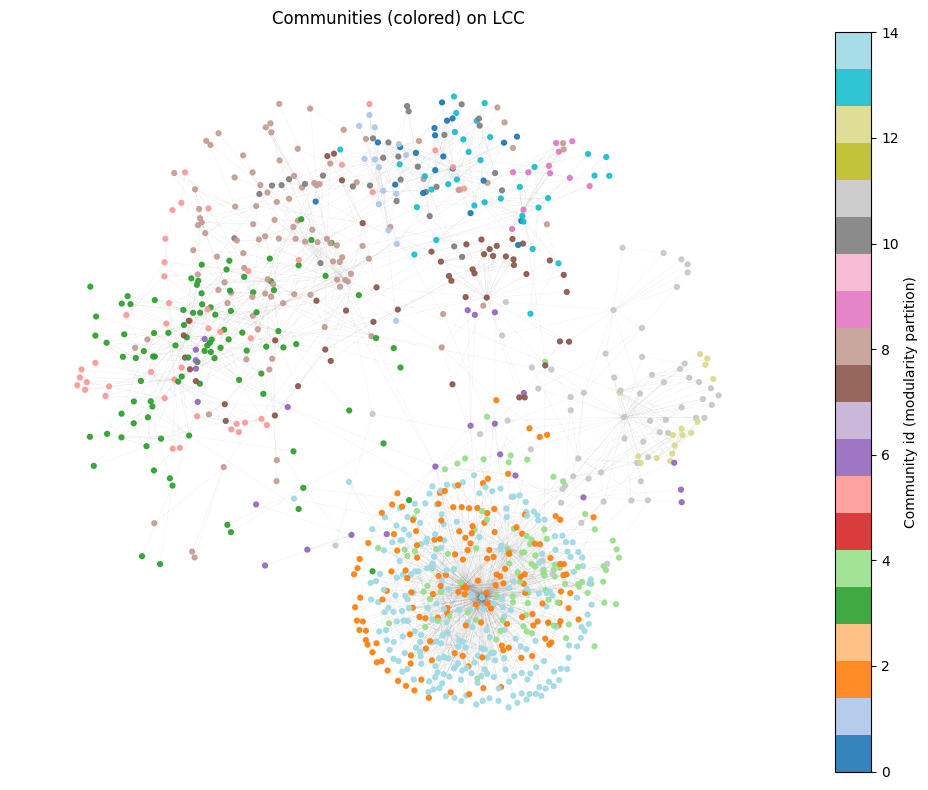

In [10]:
# --- Color nodes by community (LCC visualization) ---
comm_colors = np.array([partition.get(i, -1) for i in G_cent.nodes()])
pos2 = nx.spring_layout(G_cent, seed=7, k=0.12)

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G_cent, pos2, alpha=0.06, width=0.4)
sc = nx.draw_networkx_nodes(
    G_cent,
    pos2,
    node_size=12,
    node_color=comm_colors,
    cmap=plt.cm.tab20,
    alpha=0.9,
)
plt.axis("off")
plt.title("Communities (colored) on LCC")
plt.colorbar(sc, label="Community id (modularity partition)")
plt.tight_layout()
plt.show()


**Interpretation:** **Communities** are groups of products with comparatively dense internal co-purchasing. Retailers might use them for **bundling**, **recommendations**, or **category** discovery (subject to data ethics and business rules).


## 9. Filtering and Highlighting

We identify **top-5 betweenness** nodes and **high-degree** seeds as the **union** of (a) the **top 10%** of nodes by degree rank and (b) nodes with degree **≥ the 90th percentile** of degree values. We then build a **subgraph** induced by those seeds **plus their one-hop neighbors** and plot it.


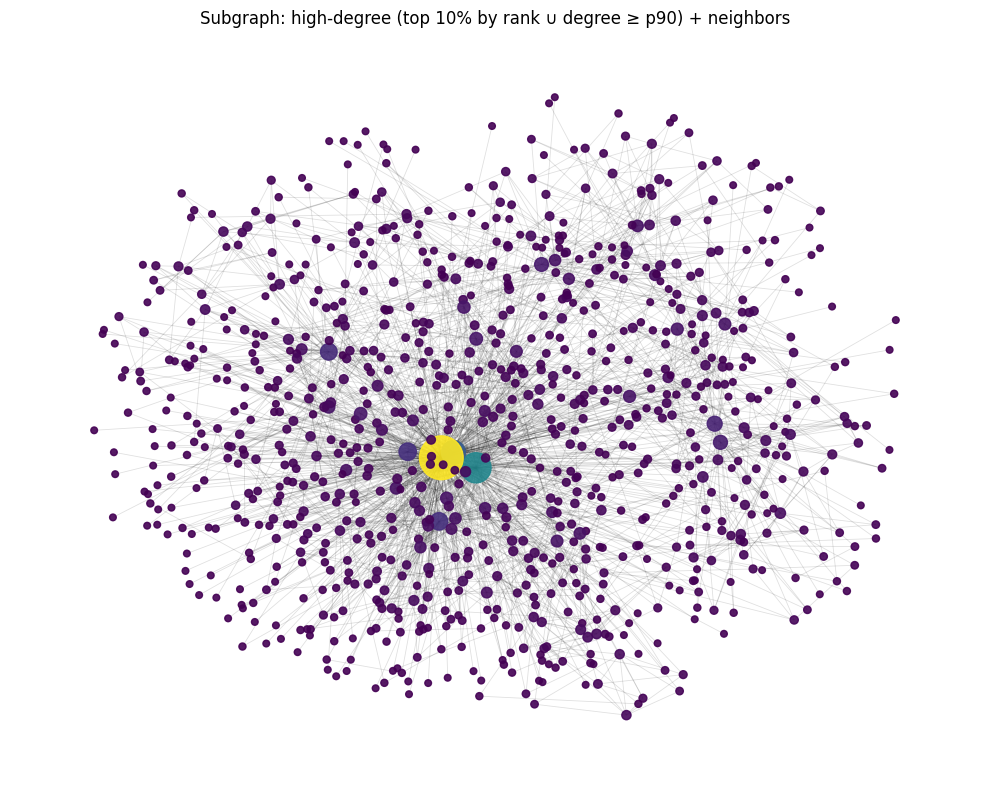

Top 5 betweenness nodes: [24139, 38365, 58064, 458358, 522711]
High-degree seed count (union top-10% rank and ≥p90): 137


In [11]:
# --- High-degree: union of (i) top 10% by rank and (ii) degree >= 90th percentile ---
deg_series = pd.Series(deg).sort_values(ascending=False)
k = max(1, int(np.ceil(0.10 * len(deg_series))))
top10_by_rank = set(deg_series.index[:k])
p90_val = float(np.percentile(deg_series.values, 90))
high_p90 = set(deg_series[deg_series >= p90_val].index)
high_deg_nodes = top10_by_rank | high_p90

# Expand by one hop (neighbors)
sub_nodes = set(high_deg_nodes)
for u in list(high_deg_nodes):
    sub_nodes.update(G.neighbors(u))

G_highlight = G.subgraph(sub_nodes).copy()
pos_h = nx.spring_layout(G_highlight, seed=99, k=0.25)

# Color by degree for readability
deg_h = dict(G_highlight.degree())
node_sizes = [20 + 3 * deg_h[n] for n in G_highlight.nodes()]
colors = [deg_h[n] for n in G_highlight.nodes()]

plt.figure(figsize=(10, 8))
nx.draw_networkx_edges(G_highlight, pos_h, alpha=0.12, width=0.6)
nx.draw_networkx_nodes(
    G_highlight, pos_h, node_size=node_sizes, node_color=colors, cmap=plt.cm.viridis, alpha=0.9
)
plt.axis("off")
plt.title("Subgraph: high-degree (top 10% by rank ∪ degree ≥ p90) + neighbors")
plt.tight_layout()
plt.show()

top5_bet_set = set(bet_df.head(5)["Node"])
print("Top 5 betweenness nodes:", sorted(top5_bet_set))
print(
    "High-degree seed count (union top-10% rank and ≥p90):",
    len(high_deg_nodes),
)


**Interpretation:** The **core** shows locally dense co-purchase structure around popular products. **Neighbors** reveal immediate “ecosystem” items often bought alongside hubs.


## 10. Highlight Top 5 Degree Nodes

We emphasize the **five highest-degree** nodes (same IDs as in Section 6): **larger**, **black**, with **labels** for those that appear on the **LCC** plot; other nodes are smaller and lighter. If the graph has several components, a global top-degree node might lie outside the LCC and will not be visible here. Figure saved to **`outputs/week4/top5_degree_highlighted.png`**.


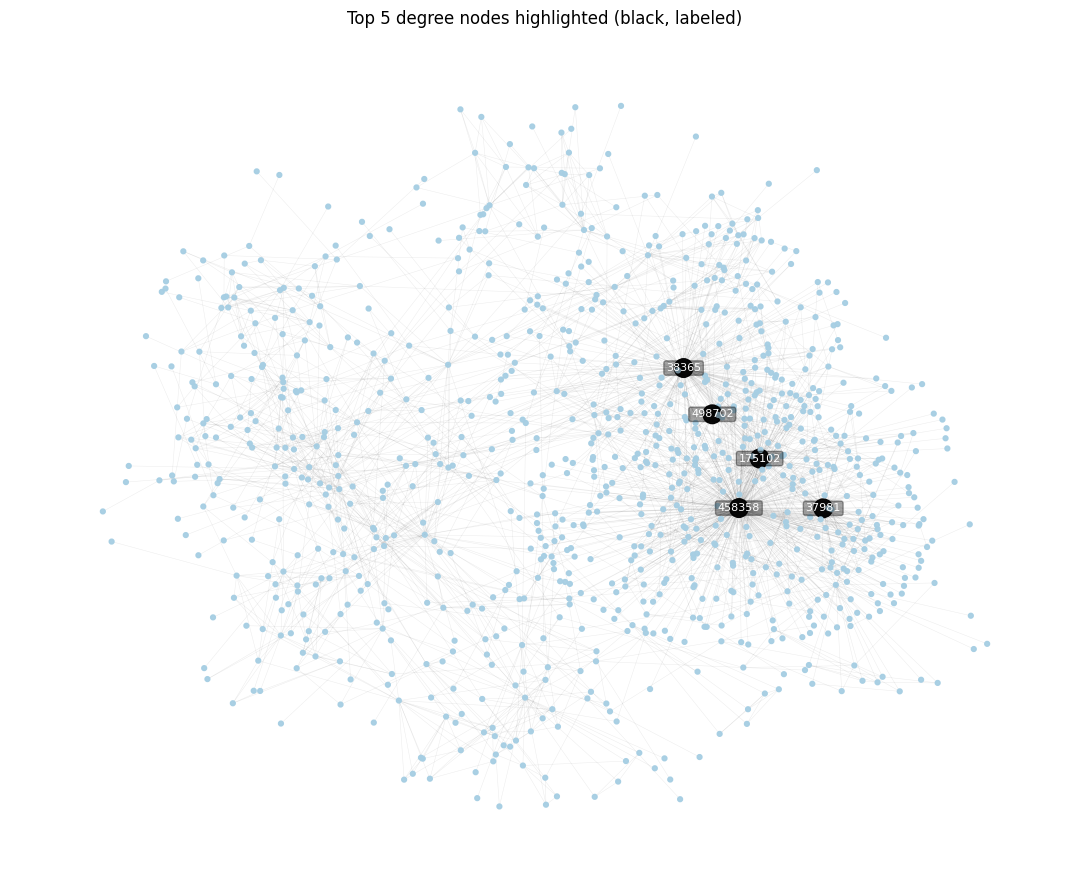

Saved: outputs/week4/top5_degree_highlighted.png


In [12]:
# --- Final highlight plot on LCC (global top-5 degree; only nodes in LCC are drawn large/black) ---
top5_deg = list(deg_df.head(5)["Node"])  # same ranking as Section 6 / Moodle table
top5_deg_set = set(top5_deg)

G_plot = G_lcc
pos_f = nx.spring_layout(G_plot, seed=1, k=0.15)

node_color = []
node_size = []
for n in G_plot.nodes():
    if n in top5_deg_set:
        node_color.append("black")
        node_size.append(180)
    else:
        node_color.append("#A6CEE3")
        node_size.append(12)

plt.figure(figsize=(11, 9))
nx.draw_networkx_edges(G_plot, pos_f, alpha=0.07, width=0.4)
nx.draw_networkx_nodes(G_plot, pos_f, node_size=node_size, node_color=node_color, alpha=0.95)
nx.draw_networkx_labels(
    G_plot,
    pos_f,
    labels={n: str(n) for n in top5_deg if n in G_plot},
    font_size=8,
    font_color="white",
    bbox=dict(boxstyle="round,pad=0.2", facecolor="black", alpha=0.35),
)
plt.axis("off")
plt.title("Top 5 degree nodes highlighted (black, labeled)")
out_png = OUT_DIR / "top5_degree_highlighted.png"
plt.tight_layout()
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print("Saved:", out_png.relative_to(PROJECT_ROOT))


## 11. Export Enriched Graph for Gephi

We export node attributes useful in Gephi’s **Data Laboratory** and **Appearance** panels:

**`amazon_nodes_with_metrics_for_gephi.csv`:** `Id`, `Degree`, `Betweenness`, `PageRank`, `Community`, `Is_Top5_Degree`, `Is_Top5_Betweenness`

**Edges:** `Source`, `Target` (same as before)

**`amazon_graph_with_metrics.gexf`:** single file including attributes where supported.

In Gephi you can **size** by **Degree**, **color** by **Community**, **filter** **Is_Top5_Degree**, and **select** high **Betweenness** to explain **bridge** products in your report.


In [13]:
# --- Build enriched node table for all nodes in G ---
top5_bet_list = list(bet_df.head(5)["Node"])
is_top5_deg = {n: (n in top5_deg_set) for n in G.nodes()}
is_top5_bet = {n: (n in set(top5_bet_list)) for n in G.nodes()}

rows = []
for n in G.nodes():
    rows.append(
        {
            "Id": n,
            "Degree": deg.get(n, 0),
            "Betweenness": bet_full.get(n, np.nan),
            "PageRank": pr_full.get(n, np.nan),
            "Community": int(G.nodes[n].get("community", -1)),
            "Is_Top5_Degree": bool(is_top5_deg.get(n, False)),
            "Is_Top5_Betweenness": bool(is_top5_bet.get(n, False)),
        }
    )

nodes_enriched = pd.DataFrame(rows)
nodes_enriched.sort_values("Degree", ascending=False).head()

nodes_enriched.to_csv(OUT_DIR / "amazon_nodes_with_metrics_for_gephi.csv", index=False)
edges_export.to_csv(OUT_DIR / "amazon_edges_for_gephi.csv", index=False)

# Attach attributes for gexf export copy
G_export = G.copy()
for _, r in nodes_enriched.iterrows():
    nid = r["Id"]
    G_export.nodes[nid]["Degree"] = int(r["Degree"])
    G_export.nodes[nid]["Betweenness"] = float(r["Betweenness"]) if pd.notna(r["Betweenness"]) else 0.0
    G_export.nodes[nid]["PageRank"] = float(r["PageRank"]) if pd.notna(r["PageRank"]) else 0.0
    G_export.nodes[nid]["Community"] = int(r["Community"])
    G_export.nodes[nid]["Is_Top5_Degree"] = str(bool(r["Is_Top5_Degree"]))
    G_export.nodes[nid]["Is_Top5_Betweenness"] = str(bool(r["Is_Top5_Betweenness"]))

nx.write_gexf(G_export, OUT_DIR / "amazon_graph_with_metrics.gexf")

print("Wrote enriched exports under outputs/week4/")


Wrote enriched exports under outputs/week4/


## 12. Summary

- The co-purchase data were modeled as an **undirected** graph suitable for co-occurrence analysis.
- **Degree** highlighted **highly connected** products in the sampled network.
- **Betweenness** helped find **bridge** products between regions of the graph (computed on the **LCC**, with **approximation** if the graph is large).
- **PageRank** surfaced nodes **endorsed** by influential neighborhoods.
- **Community detection** suggested **product groupings** for further business interpretation.
- **Gephi** remains the go-to tool for **interactive** layout and presentation; Python ensures **reproducible** metrics and exports.


## 13. Student Task / Submission (Moodle)

Submit:

1. **Completed notebook** (all cells run, figures visible).
2. **Screenshot** of a **Gephi** visualization (layout + styling of your choice).
3. **Table:** top **5** nodes by **degree** (from Section 6).
4. **Table:** top **5** nodes by **betweenness** (from Section 7).
5. **Table:** top **5** nodes by **PageRank** (from Section 7).
6. **Short paragraph** explaining the **role** of the most important nodes (hubs vs bridges vs community anchors), grounded in your numbers and the Gephi view.

**Reminder:** Use the exported CSV/GEXF files under **`outputs/week4/`** for Gephi import.
